In [1]:
import cv2
import numpy as np

### Intermediate step 1

For step 1 just use numpy, as it is fast and easy to read. We can subtract two images just with a minus sign if they have same shape. This means the code works on templates, full size images and both in colour and greyscale.

In [2]:
# 1. Subtract corresponding pixel intensities: img1[y, x] - img2[y, x]
# 2. Take the absolute value of each difference: |img1[y, x] - img2[y, x]|
# 3. Sum these absolute differences over all pixels
# ==> Sum of absolute differences = sum_y sum_x |img1[y, x] - img2[y, x]|

def absSumDiffImage(img1, img2):
    if img1.shape != img2.shape:
        raise ValueError("Images must have the same dimensions!")
    return np.sum(np.abs(img1 - img2))

In [3]:
# I'm loading in as int16 because I had issues with overflow
img_left = np.int16(cv2.imread("nose_left.png"))
img_right = np.int16(cv2.imread("nose_right.png"))

print(absSumDiffImage(img_left,img_right))

22971


### Intermediate step 2

We check the fit on each image and store that in a list, then np.argmin can return the index with the best fit / smallest mismatch.

In [4]:
# Images to be compared to img_left
paths = ["nose1.png","nose2.png","nose3.png"]
# Storing a score for every image
difs = [0,0,0]

# Iterate through all images
for i in range(len(paths)):
    img_p = np.int16(cv2.imread(paths[i]))
    # Calculate absSumDiffImage between img_left and each of the images in 'paths'
    dif = absSumDiffImage(img_left,img_p)
    print(f"With image: {i+1} abs dif is: {dif}") # +1 is conversion from 0 index
    # Store each score in 'difs'
    difs[i] = dif

# np.argmin returns the index of the lowest score
print("Best fit is at" , np.argmin(difs) +1) # +1 is conversion from 0 index

With image: 1 abs dif is: 4083
With image: 2 abs dif is: 357
With image: 3 abs dif is: 4470
Best fit is at 2


### Intermediate step 3:

This code should work no matter if the image is grayscale or not. We decided to go with colour, but the code can easily be used in grayscale if images are loading in as grayscale. Thats because the absSumDiff also works for both grayscale and colour since Numpy has the same syntax no matter the dimensions of the image/array. The choice to use colour was because we saw better result during the template matching, as we have 3x the amount of data to choice the best fit (of course some of the colour channels are correlated, so its not truly 3x the amount of information)
The code is structured to run through the length of the slice/span in a for loop and check the absSumDiff at every spot except first and last 3. Here we set the diff to np.inf so we are sure to never select these spots. Then np.argmin will return the correct index.

In [5]:
def findMatch(img_slice, template):
    # Count how many columns img_slice has
    span = img_slice.shape[1]
    # Create an array of zeros, one for each column --> Each value will have the matching score for that position
    difs_span = np.zeros(span)

    # Assuming height is always 7, with 4 as middle pixel
    for i in range(span):
        # skip centres where the 7-column block would go outside the image
        if i < 3 or i > span -4:
            difs_span[i] = np.inf
            continue

        # Selecting all rows and 7 columns centred at column i (the end index i+4 is excluded)
        img_current = img_slice[:,i-3:i+4]
        
        # Calculate the sum of absolute differences between this block and the template: a lower score means a better match in pixel values
        difs_span[i] = float(absSumDiffImage(img_current, template))
    
    # Returns index for which the dif was lowest ie best match
    return np.argmin(difs_span) 

img_nose_span = np.int16(cv2.imread("nose_span.png"))

print("Best fit is at pixel" , findMatch(img_nose_span, img_left)) 

Best fit is at pixel 135


Challenge

We tried running it in grayscale first, be the results where kinda so-so, so all codes is now changed to run in colour. Surprisingly even though this increases our datasize by 300% the time it takes to run the code only increases about 10%. Goes to show numpy is not the bottle neck, the python for loops are.


In [6]:
tsukuba_left = np.int16(cv2.imread("tsukuba_left.png"))
tsukuba_right = np.int16(cv2.imread("tsukuba_right.png"))

#Im gonna make a movement map and then store where I find the template match
movement_map = np.zeros_like(tsukuba_left[:,:,0]) #The movement map should only be in 2D

rows = movement_map.shape[0]
columns = movement_map.shape[1]

We build a double for-loop going through every pixel in one image and then scanning the whole row in the other image and finding the best match. This means the code is $O(r^2 * c)$ with r being number of rows and c being number of columns. This is why this code runs so slow. Better algorithms can for sure be implemented.
Edge cases are set to a movement of 0 since we cannot fit our mask inside these areas.

In [8]:
for i in range(rows):
    if i%10 == 0:
        print("Rows are", int((i/rows)*100),r"% finished")
    for j in range(columns):
        if (i < 3 or i > rows -4) or (j < 3 or j > columns -4):
            #We assume no movement on the edges since we cannot compute it
            movement_map[i,j] = 0
            continue

        current_template = tsukuba_left[i-3:i+4,j-3:j+4]
        movement_map[i,j] = findMatch(tsukuba_right[i-3:i+4,:],current_template) - j 
        # subtract j as it is the current column index and we want movement not position of match 
print(f"Rows are 100 % finished")     

Rows are 0 % finished
Rows are 3 % finished
Rows are 6 % finished
Rows are 10 % finished
Rows are 13 % finished
Rows are 17 % finished
Rows are 20 % finished
Rows are 24 % finished
Rows are 27 % finished
Rows are 31 % finished
Rows are 34 % finished
Rows are 38 % finished
Rows are 41 % finished
Rows are 45 % finished
Rows are 48 % finished
Rows are 52 % finished
Rows are 55 % finished
Rows are 59 % finished
Rows are 62 % finished
Rows are 65 % finished
Rows are 69 % finished
Rows are 72 % finished
Rows are 76 % finished
Rows are 79 % finished
Rows are 83 % finished
Rows are 86 % finished
Rows are 90 % finished
Rows are 93 % finished
Rows are 97 % finished
Rows are 100 % finished


I added the print statement of how far the code is because it takes around 5 minutes to run, and I was getting impatient so I wanted to know if it was soon done.

In [10]:
import matplotlib.pyplot as plt

Below i try to visualize the output. In this code positive movement and negative movement are both possible, as they corrispond to left and right movement. If a object did not move it is assigned as 0, and the border is also given 0 as there is no well defigned way to run a 7x7 pixel template in the first 3 and last 3 rows.

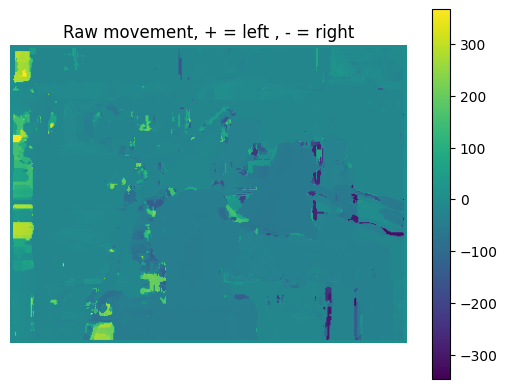

In [11]:
#Can visualise it a bit

plt.imshow(movement_map, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Raw movement, + = left , - = right")
plt.show()

Average movement is: -22.76385271990741


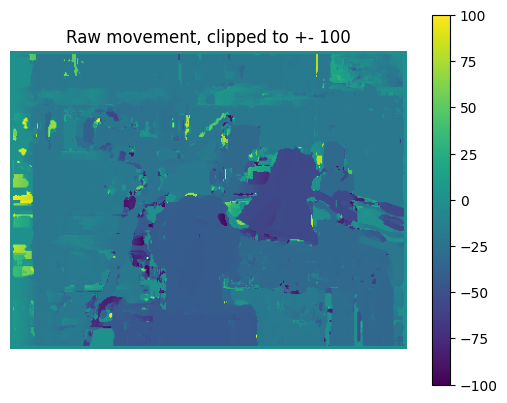

In [12]:
movement_map_copy = movement_map.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy > 100) | (movement_map_copy < -100)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Raw movement, clipped to +- 100")
plt.show()

Average movement is: 7.23779296875


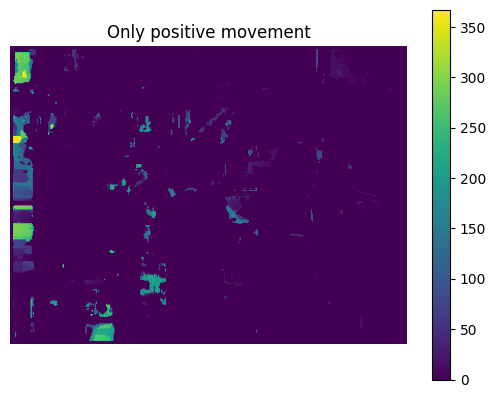

In [13]:
movement_map_copy = movement_map.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy < 0)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Only positive movement")
plt.show()

It is quite clear that the positive movement (right movement) is noise. There is no clear pattern in the image.

Average movement is: -27.27396195023148


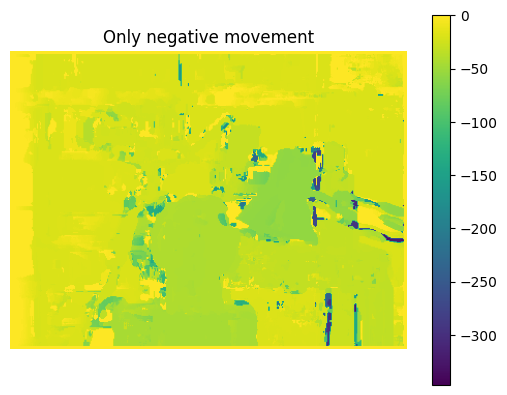

In [14]:
movement_map_copy = movement_map.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy > 0)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Only negative movement")
plt.show()

The negative movement is better, but some moves are of length 300, which is almost a full image. This is clearly also noise, as per human inspection i can see that the lamp moved the most, and it only moved maximum of 50-70 px. I therefore clip the image to remove noise, since I know no true movement was longer than 100 px.

Average movement is: 1.3401059751157407


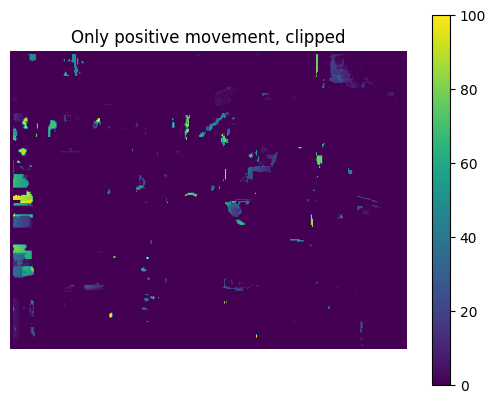

In [15]:
movement_map_copy = movement_map.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy < 0) | (movement_map_copy > 100)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Only positive movement, clipped")
plt.show()

Average movement is: -24.10395869502315


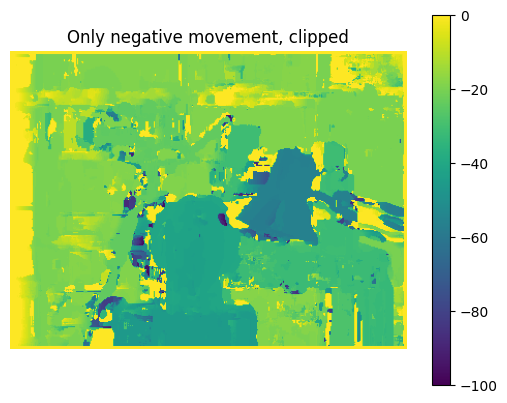

In [16]:
movement_map_copy = movement_map.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy > 0) | (movement_map_copy < -100)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Only negative movement, clipped")
plt.show()

This is then the best estimate of the true movement of objects. This comparison between templates was done in colour space, it was movement that is negative in the output of this code, and all movements longer than 100 px is removed, since we know they were noise. In this image we can clearely see that the lamp and the bust (statue) moved, and that the lamp moved more (it has a darker value meaning more movement)